In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sklearn.metrics as skm
from matplotlib import pyplot as plt
import glob
import re
import time

# path = Path('/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v6')
path = Path('/mnt/data/biliseq_he_class/proc/v6') #singularity --bind compatible (project dir to /mnt)
# path = Path('/m')
use = 'tiles'
re_class= r"class_(.+)_x\d+_y\d+.jpg"
re_slide =r'(.+)_class_\S+_x\d+_y\d+.jpg$'
re_slide_class=r'(.+)_class_(.+)_x\d+_y\d+.jpg$'
slides=[]
slides_c=[]
all_c=[]
all_f=[]
fns = glob.glob(str(path.joinpath(use)) + '/*.jpg')
for f in fns:
    fn=Path(f).parts[-1]
    all_f.append(fn)
    slide, c = re.findall(re_slide_class,fn)[0]
    slides_c.append("%s_%s" % (slide,c))
    slides.append(slide)
    all_c.append(c)
print(np.unique(slides_c),len(slides_c))

['1007466_neg' '1007467_neg' '1007468_neg' '1007469_neg' '1007470_neg'
 '1007471_neg' '1007473_neg' '1007474_neg' '1007476_pos' '1007477_pos'
 '1007478_pos' '1007482_pos' '1007484_pos' '1007485_pos' '1007486_pos'
 '1007720_neg' '1007726_neg' '1007731_pos' '1007733_pos' '1007820_neg'
 '1007821_neg' '1007822_neg' '1007824_neg' '1007825_neg' '1007826_pos'
 '1007827_pos' '1007828_pos' '1007829_pos' '1007830_pos' '1007831_pos'
 '1007832_pos' '1007845_neg' '1007846_neg' '1007847_neg' '1007848_neg'] 51813


In [19]:
test_df.head()

,Unnamed: 0.1,Unnamed: 0,fn,slide,class,is_valid,full_path,p_pos,pred_cls
0,0,0,1007832_class_pos_x13750_y3750.jpg,1007832,pos,1,/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-...,0.932145,1
1,1,1,1007832_class_pos_x4500_y70500.jpg,1007832,pos,1,/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-...,0.998756,1
2,2,2,1007720_class_neg_x26250_y9500.jpg,1007720,neg,1,/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-...,0.025553,0
3,3,3,1007484_class_pos_x5500_y113000.jpg,1007484,pos,1,/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-...,0.998436,1
4,4,4,1007720_class_neg_x22750_y93250.jpg,1007720,neg,1,/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-...,0.014755,0


In [3]:
#Generate fold_summary.csv
#Warning the model_type='resnet18_10fold10rep'  .csv files were overwritten by wrong model output so
#only use fold summary to re examine this model at this time... -BI

nslides=len(np.unique(slides_c))
# model_type= 'resnet18_24train_100rep_500bal' #'resnet18_10fold10rep'  #'resnet18_jackknife_v0'
# model_type = 'resnet18_10fold_10rep_500bal_10ft' #'resnet34_10fold10rep'
model_type='resnet18_10fold10rep' 
use='tiles'
# use='summary'
start=0
stop=100 #Folds x reps  (Currently bugging on fold 99 --> why??)
u_slides_c=np.unique(slides_c)
temp = [item.split('_') for item in u_slides_c]
fold_df=pd.DataFrame(temp,columns=['slide','class'])
s=time.time()

model_path='%s_model' % use
export_path=path.joinpath(model_path).joinpath(model_type).joinpath('fold_models')
csv_path=path.joinpath(model_path).joinpath(model_type).joinpath('csv')
infer_path=path.joinpath(model_path).joinpath(model_type).joinpath('infer_csv')

for fold in range(start,stop):
    print('Perform inference on fold :', fold)
    df=pd.read_csv(infer_path.joinpath('fold_%d_all_valid_pred.csv' % fold))
    test_df=df.loc[df.loc[:,'is_valid']==1,:].reset_index(drop=True)
    test_slides=np.unique(test_df.loc[:,'slide'])
    p=np.array(test_df.loc[:,'p_pos']) # Probability ['neg','pos'] (Can check with dls.vocab )
    c=np.array(test_df.loc[:,'pred_cls']) #Predictions decoded
    fold_df['p1_fold_%d' % fold] = np.zeros((fold_df.shape[0],1))*np.nan
    for slide in test_slides:
        src_idx = np.array(test_df.loc[:,'slide']) == slide
        p1 = np.mean(p[src_idx])
        dest_idx = np.array(fold_df.loc[:,'slide'])== str(slide)
        fold_df.loc[dest_idx,'p1_fold_%d' % fold] = p1
ss=time.time()
print('Wall time: %ds' % (ss-s))


fn=infer_path.joinpath('fold_summary.csv')
# print('Saving inference summary to %s' % fn)
# fold_df.to_csv(fn) #Un-comment to save
print('Finished')

Perform inference on fold : 0
Perform inference on fold : 1
Perform inference on fold : 2
Perform inference on fold : 3
Perform inference on fold : 4
Perform inference on fold : 5
Perform inference on fold : 6
Perform inference on fold : 7
Perform inference on fold : 8
Perform inference on fold : 9
Perform inference on fold : 10
Perform inference on fold : 11
Perform inference on fold : 12
Perform inference on fold : 13
Perform inference on fold : 14
Perform inference on fold : 15
Perform inference on fold : 16
Perform inference on fold : 17
Perform inference on fold : 18
Perform inference on fold : 19
Perform inference on fold : 20
Perform inference on fold : 21
Perform inference on fold : 22
Perform inference on fold : 23
Perform inference on fold : 24
Perform inference on fold : 25
Perform inference on fold : 26
Perform inference on fold : 27
Perform inference on fold : 28
Perform inference on fold : 29
Perform inference on fold : 30
Perform inference on fold : 31
Perform inference 

<ipython-input-3-59a3024ef3bc>:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fold_df['p1_fold_%d' % fold] = np.zeros((fold_df.shape[0],1))*np.nan


In [4]:
fold_df.head()

,slide,class,p1_fold_0,p1_fold_1,p1_fold_2,p1_fold_3,p1_fold_4,p1_fold_5,p1_fold_6,p1_fold_7,...,p1_fold_90,p1_fold_91,p1_fold_92,p1_fold_93,p1_fold_94,p1_fold_95,p1_fold_96,p1_fold_97,p1_fold_98,p1_fold_99
0,1007466,neg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.53945,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1007467,neg,0.187745,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.241247,NaN,NaN,NaN,NaN
2,1007468,neg,0.329991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.31264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1007469,neg,NaN,NaN,NaN,NaN,0.181589,NaN,NaN,NaN,...,NaN,NaN,NaN,0.231684,NaN,NaN,NaN,NaN,NaN,NaN
4,1007470,neg,NaN,0.640411,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.568390,NaN,NaN,NaN,NaN


In [57]:
folds

[100]

In [76]:
np.nanmean(wta,axis=1)

<ipython-input-76-c5fa624d6ab4>:1: RuntimeWarning: Mean of empty slice
  np.nanmean(wta,axis=1)


array([0.3, 0. , 0.4, 0.3, 1. , 0.6, 0.6, 0. , 0. , 0.8, 1. , 0. , 0.9,
       1. , 0. , 0.2, nan, 0.4, 1. , 0.3, 0. , 1. , 0.9, 0.5, 0. , 1. ,
       0. , 1. , 1. , 1. , 1. , 0. , 0.1, 1. , 0.7])

<ipython-input-56-3506e788f62e>:46: RuntimeWarning: Mean of empty slice
  m_p1=np.nanmean(p1,axis=1) #Average validation performance across model repetitions for given architecture


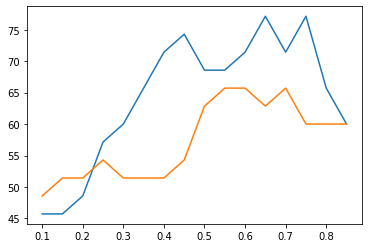

In [56]:
# model_type='resnet18_10kfold'
# model_type='resnet18_jackknife_v0'
# model_type = 'resnet18_10fold10rep' 
# model_type='resnet18_4train_100rep_500bal'
# model_type='resnet34_10fold10rep'
# use='tiles'

model_type='resnet18_10fold10rep' 
# use='summary'
if ('10k' in model_type):
    folds=[10,10]
    nslides=[35,34] #Summary models drop one slide due to insufficient data
elif  ('10fold10rep' in model_type):
    folds=[100,100]
    nslides=[35,35] #Summary models drop one slide due to insufficient data
elif 'jackknife' in model_type:
    nslides=[35,34]
    folds=[35,34]
elif ('train' in model_type) or ('10fold' in model_type):
    nslides=[35]
    folds=[100]
    
total_slides=35

#Initialize storage dataframe to tiles model:
pn = path.joinpath('%s_model' % 'tiles').joinpath(model_type).joinpath('infer_csv')
fold_df= pd.read_csv(pn.joinpath('fold_summary.csv'))
ens=pd.DataFrame(fold_df.loc[:,('slide','class')])
ans=['tiles','summary']
# ans=['tiles']

for use in ans:    
    ens['%s_p1' % use]=np.zeros((total_slides,1))+np.nan
    ens['%s_wta' % use]=np.zeros((total_slides,1))+np.nan
    
for use_fold,nslide,use in zip(folds,nslides,ans):
    pn = path.joinpath('%s_model' % use).joinpath(model_type).joinpath('infer_csv')
    fold_df= pd.read_csv(pn.joinpath('fold_summary.csv'))
    p1=[]
    # wta=[]
    for fold in range(0,use_fold):
        p1.append(np.array(fold_df.loc[:,'p1_fold_%d' % fold]))
        # wta.append(np.array(fold_df.loc[:,'wta_fold_%d' % fold]))
    p1=np.array(p1).transpose()
    # wta=np.array(wta).transpose()
    m_p1=np.nanmean(p1,axis=1) #Average validation performance across model repetitions for given architecture
    # m_wta=np.nansum(wta==1,axis=1) > np.nansum(wta==0,axis=1)
    for slide in fold_df.loc[:,'slide']:
        indx=np.argwhere(np.array(fold_df.loc[:,'slide'] == slide)).flatten()
        ens.loc[indx,'%s_p1' % use]=m_p1[indx]
        # ens.loc[indx,'%s_wta' % use]=m_wta[indx]

true_pos = np.array(ens.loc[:,'class'])=='pos'
thresh=np.arange(0.1,0.9,0.05)
plt.figure()
for use in ans:
    accuracy=[]
    for t in thresh:
        pred_pos = ens.loc[:,'%s_p1' % use]> t
        # print(np.sum(true_pos == pred_pos) / len(true_pos))
        accuracy.append(np.sum(true_pos == pred_pos) / len(true_pos) * 100)
    plt.plot(thresh,accuracy)

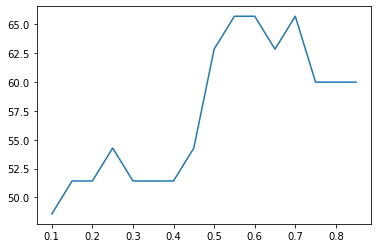

In [27]:
#Threshold tuning:
true_pos = np.array(ens.loc[:,'class'])=='pos'
thresh=np.arange(0.1,0.9,0.05)
accuracy=[]
for t in thresh:
    pred_pos = m_p1 > t
    # print(np.sum(true_pos == pred_pos) / len(true_pos))
    accuracy.append(np.sum(true_pos == pred_pos) / len(true_pos) * 100)
plt.figure()
plt.plot(thresh,accuracy)

In [36]:
print(fold_df.shape)

(35, 203)


0.7714285714285715
[[15  4]
 [ 4 12]]
0.7714285714285715


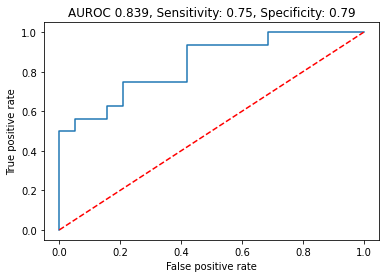

<Figure size 432x288 with 0 Axes>

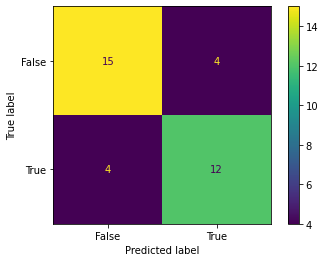

In [57]:
m_p1 = ens.loc[:,'tiles_p1']
true_pos = np.array(ens.loc[:,'class'])=='pos'

pred_pos = m_p1 > 0.65
use = ~np.isnan(m_p1)

print(np.sum(pred_pos[use] == true_pos[use]) / np.sum(use) )

fpr,tpr,thresh =skm.roc_curve(true_pos[use],m_p1[use])
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--r')
c=skm.confusion_matrix(true_pos[use],pred_pos[use])

auc=skm.auc(fpr,tpr)

plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
print(c)
tn=c[0][0]
tp=c[1][1]
fn=c[1][0]
fp=c[0][1]

sensitivity = tp/(tp + fn) #True pos / all positive
# print('sensitivity',sensitivity)

specificity = tn/(fp + tn)
# print('specificity',specificity) #True neg / all negative
plt.title('AUROC %1.3f, Sensitivity: %1.2f, Specificity: %1.2f'% (auc,sensitivity,specificity))

f=plt.figure();
b=skm.ConfusionMatrixDisplay.from_predictions(true_pos,pred_pos)
print(np.sum(true_pos == pred_pos) / len(true_pos))

# Example of ROC with std

(35, 100)


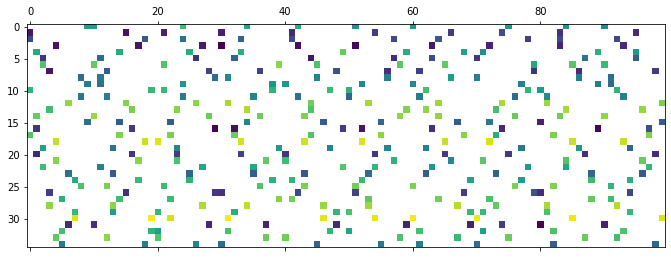

In [60]:
use_dat = []
for col in fold_df.columns:
    if 'p1_fold' in col:
        use_dat.append(fold_df.loc[:,col].values)
use_dat=np.array(use_dat).T
print(use_dat.shape)
plt.matshow(use_dat)

In [38]:
np.nanmean(use_dat[:,10:20],axis=1)

<ipython-input-38-20566f6028e4>:1: RuntimeWarning: Mean of empty slice
  np.nanmean(use_dat[:,10:20],axis=1)


array([0.48872168, 0.2228576 , 0.53622812, 0.38634542, 0.80558906,
       0.48922518, 0.54587231, 0.16771747, 0.2964226 , 0.50526959,
       0.80815482, 0.46494146, 0.5716554 , 0.6624933 , 0.34159805,
       0.43382135,        nan, 0.42621786, 0.86409132, 0.27282949,
       0.08856641, 0.68837162, 0.9576358 , 0.43017539, 0.26676747,
       0.98102991, 0.32041695, 0.89728928, 0.75979906, 0.59340822,
       0.86538505, 0.33226404, 0.45171872, 0.73051341, 0.56928008])

In [44]:
fprs[1]

array([0.        , 0.        , 0.05555556, 0.05555556, 0.11111111,
       0.11111111, 0.22222222, 0.22222222, 0.38888889, 0.38888889,
       0.5       , 0.5       , 0.66666667, 0.66666667, 0.72222222,
       0.72222222, 0.77777778, 0.77777778, 0.83333333, 0.83333333,
       1.        ])

<ipython-input-58-a283d6bb10d2>:15: RuntimeWarning: Mean of empty slice
  mean_prob_pos = np.nanmean(use_dat,axis=1)


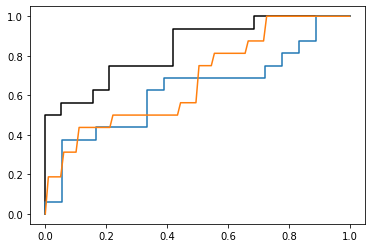

In [58]:
p1=[]
use_fold = 100
use = 'tiles'
model_type='resnet18_10fold10rep' 
pn = path.joinpath('%s_model' % use).joinpath(model_type).joinpath('infer_csv')
fold_df= pd.read_csv(pn.joinpath('fold_summary.csv'))
for fold in range(0,use_fold):
    p1.append(np.array(fold_df.loc[:,'p1_fold_%d' % fold]))
p1=np.array(p1).transpose()
m_p1=np.nanmean(p1,axis=1)
use = ~np.isnan(m_p1)
true_pos = np.array(fold_df.loc[:,'class']) == 'pos'
fpr_all,tpr_all, _ =skm.roc_curve(true_pos[use],m_p1[use])
plt.plot(fpr_all,tpr_all,'k')
mean_prob_pos = np.nanmean(use_dat,axis=1)
use = ~np.isnan(mean_prob_pos) #occassionally not all slides have a prediction due to class balancing
fpr,tpr,thresh =skm.roc_curve(true_pos[use],m[use])
plt.plot(fpr,tpr)
plt.plot(mean_fpr,tprs[0])

In [64]:
true_pos[use]

array([False, False, False, False, False, False, False, False,  True,
        True,  True,  True,  True,  True,  True, False, False,  True,
        True, False, False, False, False, False,  True,  True,  True,
        True,  True,  True,  True, False, False, False, False])

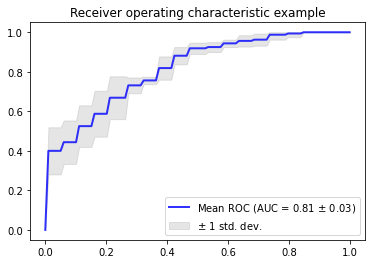

In [65]:
# Example from https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc_crossval.html
true_pos = np.array(fold_df.loc[:,'class'])=='pos'
mean_fpr = np.linspace(0, 1, 100)
use_data = np.array(p1)
fold_val = []
tprs = []
aucs = []
fig, ax = plt.subplots()
for i in range(0,100,10): #Folds * reps
    start = i
    stop = start + 10 # Capture each fold of this repetition
    mean_prob_pos = np.nanmean(use_dat[:,start:stop],axis=1)
    use = ~np.isnan(mean_prob_pos) #occassionally not all slides have a prediction due to class balancing
    fpr,tpr,thresh =skm.roc_curve(true_pos[use],mean_prob_pos[use])
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0]=0
    aucs.append(skm.auc(fpr,tpr))
    tprs.append(interp_tpr)
    fold_val.append(mean_prob_pos)
    
fold_val = np.array(fold_val).T
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = skm.auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(
    mean_fpr,
    mean_tpr,
    color="b",
    label=r"Mean ROC (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="grey",
    alpha=0.2,
    label=r"$\pm$ 1 std. dev.",
)


ax.set(
    xlim=[-0.05, 1.05],
    ylim=[-0.05, 1.05],
    title="Receiver operating characteristic example",
)
ax.legend(loc="lower right")
plt.show()

In [ ]:
m_p1 = ens.loc[:,'tiles_p1']
true_pos = np.array(ens.loc[:,'class'])=='pos'

pred_pos = m_p1 > 0.65
use = ~np.isnan(m_p1)

print(np.sum(pred_pos[use] == true_pos[use]) / np.sum(use) )

fpr,tpr,thresh =skm.roc_curve(true_pos[use],m_p1[use])
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--r')
c=skm.confusion_matrix(true_pos[use],pred_pos[use])

auc=skm.auc(fpr,tpr)

plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
print(c)
tn=c[0][0]
tp=c[1][1]
fn=c[1][0]
fp=c[0][1]

sensitivity = tp/(tp + fn) #True pos / all positive
# print('sensitivity',sensitivity)

specificity = tn/(fp + tn)
plt.title('AUROC %1.3f, Sensitivity: %1.2f, Specificity: %1.2f'% (auc,sensitivity,specificity))

f=plt.figure();
b=skm.ConfusionMatrixDisplay.from_predictions(true_pos,pred_pos)
print(np.sum(true_pos == pred_pos) / len(true_pos))

0.7142857142857143
[[14  5]
 [ 5 11]]
0.7142857142857143


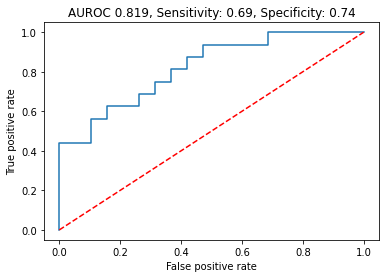

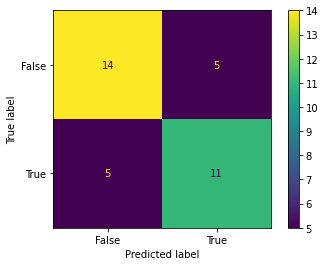

In [7]:
weights=[.8,.2]
ans=['tiles','summary']
t=np.array(ens.loc[:,'%s_p1' % 'tiles'])
temp=np.zeros(t.shape)
for w,use in zip(weights,ans):
    temp=np.nansum((temp, np.array(ens.loc[:,'%s_p1' % use])*w),axis=0)
    # temp[np.isnan(temp)]=0.5

m_p1 = temp
# m_p1= np.nanmean((np.array(ens0.loc[:,'tiles_p1']),
#                   np.array(ens2.loc[:,'tiles_p1'])),axis=0)
                  #temp #np.nanmean(ens.loc[:,('tiles_p1','summary_p1')],axis=1)
true_pos = np.array(ens.loc[:,'class'])=='pos'

pred_pos = m_p1 > 0.65
use = ~np.isnan(m_p1)

print(np.sum(pred_pos[use] == true_pos[use]) / np.sum(use) )

fpr,tpr,thresh =skm.roc_curve(true_pos[use],m_p1[use])
pred_pos = m_p1 > 0.65
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--r')
c=skm.confusion_matrix(true_pos[use],pred_pos[use])

auc=skm.auc(fpr,tpr)

plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
print(c)
tn=c[0][0]
tp=c[1][1]
fn=c[1][0]
fp=c[0][1]

sensitivity = tp/(tp + fn) #True pos / all positive
# print('sensitivity',sensitivity)

specificity = tn/(fp + tn)
# print('specificity',specificity) #True neg / all negative
plt.title('AUROC %1.3f, Sensitivity: %1.2f, Specificity: %1.2f'% (auc,sensitivity,specificity))

b=skm.ConfusionMatrixDisplay.from_predictions(true_pos,pred_pos)
print(np.sum(true_pos == pred_pos) / len(true_pos))

0.7142857142857143


<Figure size 432x288 with 0 Axes>

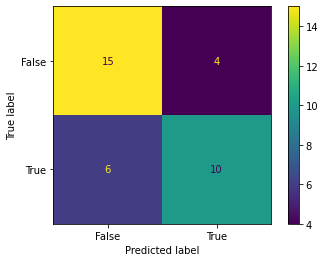

In [123]:
f=plt.figure();
pred_pos=m_p1>.7
b=skm.ConfusionMatrixDisplay.from_predictions(true_pos,pred_pos)
print(np.sum(true_pos == pred_pos) / len(true_pos))

0.6857142857142857